###Heart Disease Classification: From-Scratch NumPy Neural Network vs. Using Keras & TensorFlow



In [1]:
# ---- Environment Setup ----

import os, sys, random, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

#Import tensor and keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
tf.random.set_seed(SEED)

pd.set_option('display.max_columns', 100)


### Dataset

**Heart Disease Prediction Dataset**

This project uses the Heart Disease Dataset published on Kaggle by johnsmith88. It contains 1,025 observations and 13 predictive features, with `target` indicating the presence or absence of heart disease.

Source: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset


In [2]:
# ---- Configure dataset path ----
# Install Kaggle's dataset library
!pip install -q kagglehub

from pathlib import Path
import kagglehub
import pandas as pd

DATASET_HANDLE = "johnsmith88/heart-disease-dataset"

# Download the public dataset
dataset_directory = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

DATA_PATH = dataset_directory / "heart.csv"

if not DATA_PATH.exists():
    available_files = list(dataset_directory.iterdir())
    raise FileNotFoundError(
        f"heart.csv was not found. Available files: {available_files}"
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
df.head()

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Dataset loaded from: /kaggle/input/heart-disease-dataset/heart.csv
Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


# Part 1: Data Preparation & Analysis

### This section covers:
1. A review of shape, dtypes.
2. Basic stats per column and missing values.  
3. Visualization of the target balance and feature distributions.  
4. Simple outlier checks.  
5. Creation of **train/val/test** split with no leakage.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.shape

(1025, 14)

In [6]:
# Basic stats
display(df.describe(include='all'))
df.isna().sum()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
df.target.value_counts()

,count
target,
1,526
0,499


In [8]:
counts=df['target'].value_counts()/df.shape[0]
counts

,count
target,
1,0.513171
0,0.486829


The target variable is not imbalanced. The imbalance is when the majority class is 70%-80% of the sample.

In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
new_df = df.drop_duplicates().reset_index(drop=True)

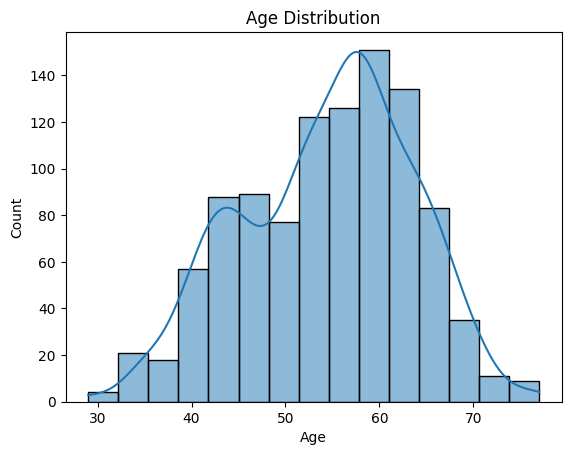

In [11]:
#Feature Distributions
sns.histplot(
    data=df,
    x="age",
    bins=15,
    kde=True,
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

In [12]:
def histogram_boxplot(data, feature, figsize=(8, 7), kde=False, bins=None):
  f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.50, 0.50)},
        figsize=figsize,
    )
  sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
  sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
  ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
  ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

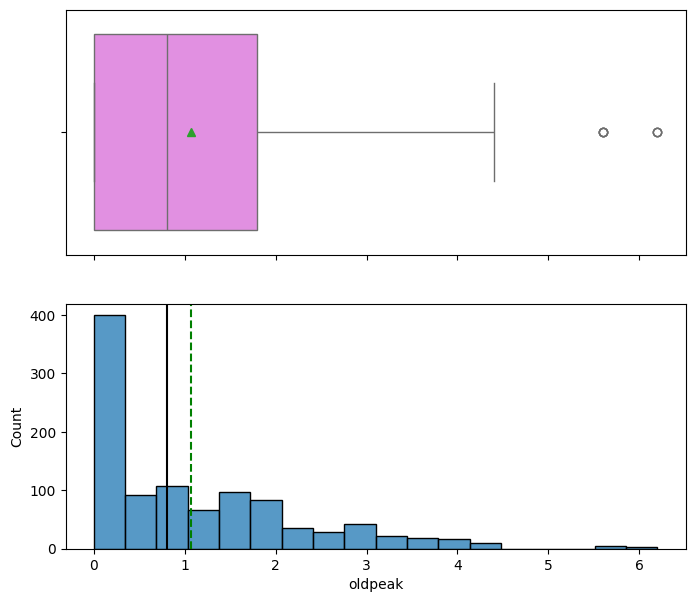

In [13]:
histogram_boxplot(df, "oldpeak")

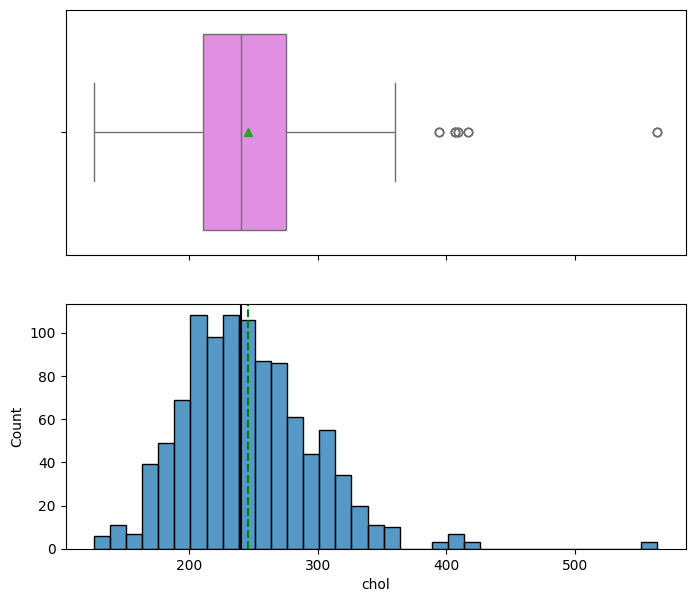

In [14]:
histogram_boxplot(df, "chol")

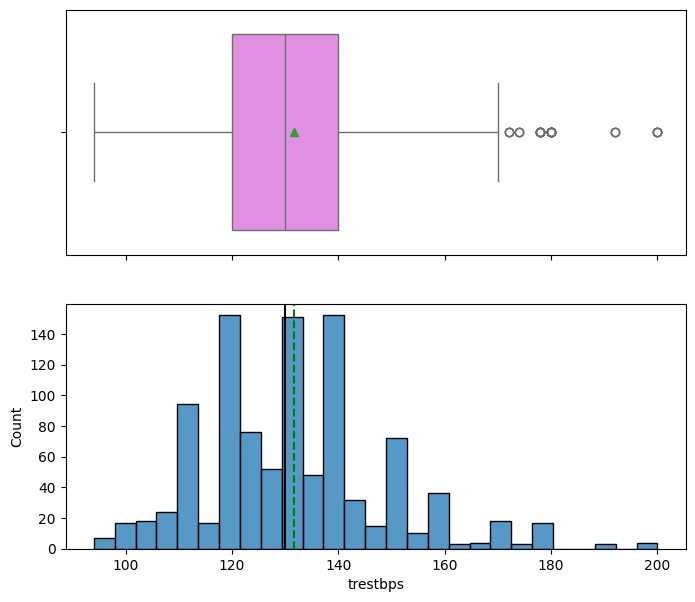

In [15]:
histogram_boxplot(df, "trestbps")

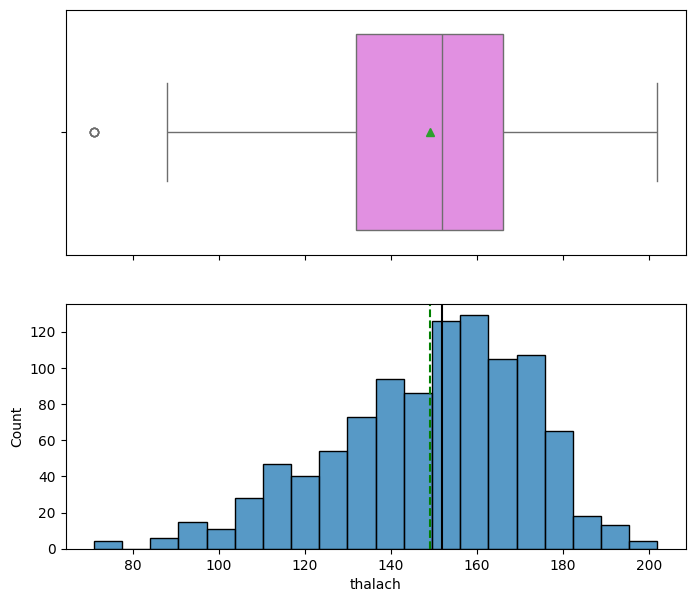

In [16]:
histogram_boxplot(df, "thalach")

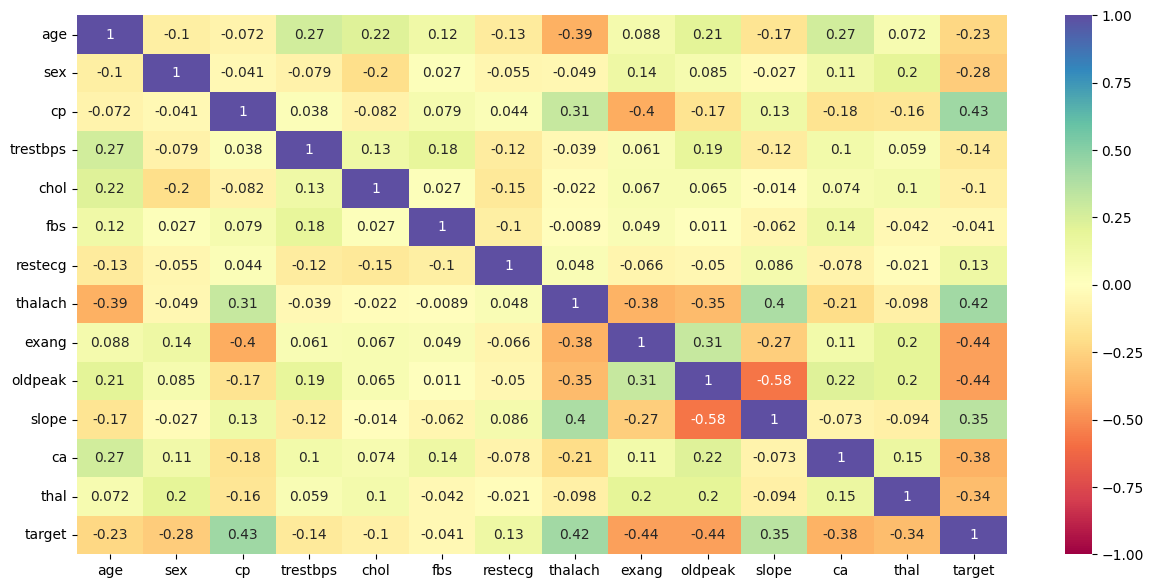

In [17]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(),annot=True,vmin=-1,vmax=1,cmap="Spectral")
plt.show()

In [18]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

/tmp/ipykernel_19403/3129855773.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


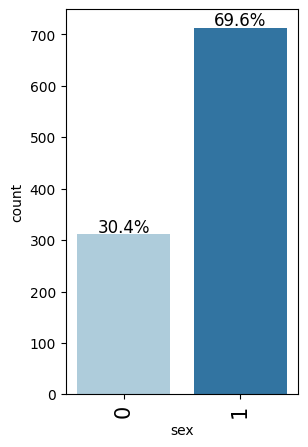

In [19]:
labeled_barplot(df,"sex",perc=True)

/tmp/ipykernel_19403/3129855773.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


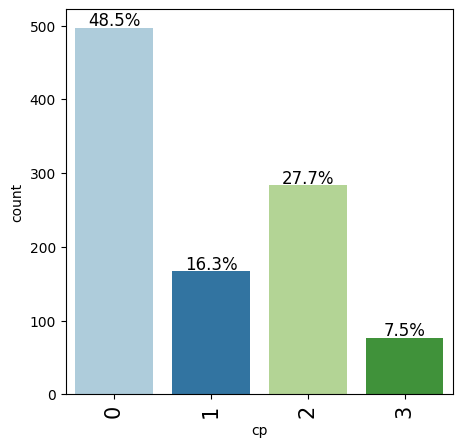

In [20]:
labeled_barplot(df,"cp",perc=True)

In [21]:
# Train/Val/Test split (no leakage)
from sklearn.model_selection import train_test_split

X = new_df.drop(columns=['target'])
y = new_df['target']

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.2, random_state=SEED, stratify=y_tmp
)
X_train.shape, X_val.shape, X_test.shape


((192, 13), (49, 13), (61, 13))

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import numpy as np

# Continuous variables
continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
]

# Categorical variables
categorical_features = [
    "cp",
    "restecg",
    "slope",
    "ca",
    "thal",
]

# Binary variables (remain unchanged)
binary_features = [
    "sex",
    "fbs",
    "exang",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            RobustScaler(),
            continuous_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
        (
            "binary",
            "passthrough",
            binary_features,
        ),
    ],
    remainder="drop",
)

# Learn medians, IQRs and categories from training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the training transformations without refitting
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = X_train_processed.astype(np.float32)
X_val_processed = X_val_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])

Original features: 13
Processed features: 27


In [80]:
print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(192, 27)
(49, 27)
(61, 27)


In [25]:
input_dim = X_train_processed.shape[1]

# Part 2: A Neural Network from Scratch using NumPy

### This section:
1. Prepares NumPy arrays.  
2. Implements forward pass (linear → sigmoid).  
3. Implements binary cross-entropy loss and backprop.  
4. Updates weights with gradient descent.  
5. Tracks loss/accuracy; evaluate on val/test.


In [26]:
# ---- NumPy scaffold ----

#Initialization is using Normal Gaussian
class TinyMLP:

    def __init__(self, input_dim, hidden_dim, output_dim, seed=SEED, learning_rate=0.01):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.01, size=(input_dim, hidden_dim))
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = rng.normal(0, 0.01, size=(hidden_dim, output_dim))
        self.b2 = np.zeros((1, output_dim))
        self.loss_history = []
        self.learning_rate= learning_rate

    #Activation function
    def sigmoid(self, z):
      z = np.clip(z, -500, 500)
      return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
      return a * (1 - a)

    def forward(self, X):
        self.z1= X @ self.W1 + self.b1
        self.a1 = self.sigmoid (self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a1, self.a2

    @staticmethod
    #Binary Cross Entropy loss function
    def compute_loss(y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    #Backward propagation_manual
    def backward (self, X, y_true, a1, a2):
        m = X.shape[0]
        #output
        d2 = (a2 - y_true) / m
        d2dw2 = a1.T @ d2
        d2db2 = np.sum(d2, axis=0)
        d1 = (d2 @ self.W2.T) * self.sigmoid_derivative(a1)
        d1dw1 = X.T @ d1
        d1db1 = np.sum(d1, axis=0)

        #gradients
        self.W2 -= self.learning_rate * d2dw2
        self.b2 -= self.learning_rate * d2db2
        self.W1 -= self.learning_rate * d1dw1
        self.b1 -= self.learning_rate * d1db1

    def train(self, X, y, epochs):
            for epoch in range(epochs):
                a1, a2 = self.forward(X)
                loss = self.compute_loss(y, a2)
                self.loss_history.append(loss)
                self.backward(X, y, a1, a2)
                self.learning_rate= 0.01
                if epoch % 100 == 0:
                  acc = self.compute_accuracy(X, y)
                  print(f"Epoch {epoch:4d}: Loss = {loss:.4f}, Accuracy = {acc:.4f}")

    def predict(self, X):
        a1, a2 = self.forward(X)
        return (a2 > 0.5).astype(int)

    def compute_accuracy(self, X, y):
      return np.mean(self.predict(X) == y)

In [27]:
X_train_np = np.asarray(X_train_processed, dtype=np.float32)
X_val_np = np.asarray(X_val_processed, dtype=np.float32)
X_test_np = np.asarray(X_test_processed, dtype=np.float32)

y_train_np = y_train.to_numpy().reshape(-1, 1).astype(np.float32)
y_val_np = y_val.to_numpy().reshape(-1, 1).astype(np.float32)
y_test_np = y_test.to_numpy().reshape(-1, 1).astype(np.float32)


In [28]:
input_dim=input_dim
hidden_dim=16
output_dim=1
model = TinyMLP(input_dim, hidden_dim, output_dim, seed=42, learning_rate=0.01)

model.train(X_train_np, y_train_np, epochs=2000)

Epoch    0: Loss = 0.6937, Accuracy = 0.4583
Epoch  100: Loss = 0.6899, Accuracy = 0.5417
Epoch  200: Loss = 0.6896, Accuracy = 0.5417
Epoch  300: Loss = 0.6895, Accuracy = 0.5417
Epoch  400: Loss = 0.6894, Accuracy = 0.5417
Epoch  500: Loss = 0.6893, Accuracy = 0.5417
Epoch  600: Loss = 0.6892, Accuracy = 0.5417
Epoch  700: Loss = 0.6891, Accuracy = 0.5417
Epoch  800: Loss = 0.6889, Accuracy = 0.5417
Epoch  900: Loss = 0.6888, Accuracy = 0.5417
Epoch 1000: Loss = 0.6886, Accuracy = 0.5417
Epoch 1100: Loss = 0.6884, Accuracy = 0.5417
Epoch 1200: Loss = 0.6882, Accuracy = 0.5417
Epoch 1300: Loss = 0.6879, Accuracy = 0.5417
Epoch 1400: Loss = 0.6876, Accuracy = 0.5417
Epoch 1500: Loss = 0.6872, Accuracy = 0.5417
Epoch 1600: Loss = 0.6867, Accuracy = 0.5417
Epoch 1700: Loss = 0.6861, Accuracy = 0.5417
Epoch 1800: Loss = 0.6854, Accuracy = 0.5417
Epoch 1900: Loss = 0.6846, Accuracy = 0.5417


In [29]:
epochs=2000
for epoch in range(epochs):
    a1, a2 = model.forward(X_train_np)
    loss = model.compute_loss(y_train_np, a2)
    model.backward(X_train_np, y_train_np, a1, a2)
    if epoch % 100 == 0:
        print(f"epoch {epoch} | loss={loss:.4f}")

epoch 0 | loss=0.6836
epoch 100 | loss=0.6824
epoch 200 | loss=0.6810
epoch 300 | loss=0.6792
epoch 400 | loss=0.6771
epoch 500 | loss=0.6746
epoch 600 | loss=0.6716
epoch 700 | loss=0.6680
epoch 800 | loss=0.6637
epoch 900 | loss=0.6586
epoch 1000 | loss=0.6525
epoch 1100 | loss=0.6455
epoch 1200 | loss=0.6373
epoch 1300 | loss=0.6279
epoch 1400 | loss=0.6173
epoch 1500 | loss=0.6054
epoch 1600 | loss=0.5923
epoch 1700 | loss=0.5781
epoch 1800 | loss=0.5630
epoch 1900 | loss=0.5472


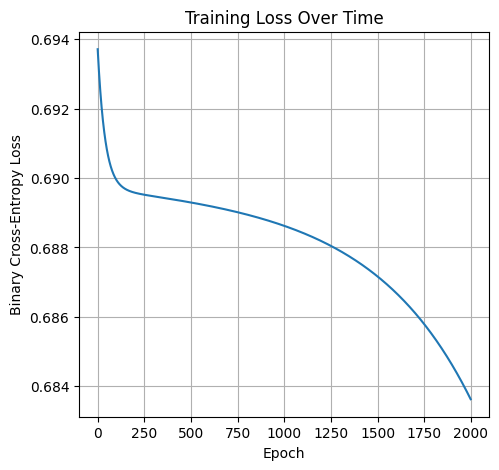

In [30]:
# Evaluation shell
plt.figure(figsize=(18, 5))

# Training loss
plt.subplot(1, 3, 1)
plt.plot(model.loss_history)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)

In [31]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [32]:
#AUC and ROC
#AUC Scores

class TinyMLP:

  def predict_proba(self, X):
    _, probabilities = self.forward(X)
    return probabilities.ravel()

  def predict(self, X, threshold=0.5):
    return (
        self.predict_proba(X) >= threshold
    ).astype(int)

In [33]:
# The second output from forward() contains sigmoid probabilities
_, val_probability_matrix = model.forward(X_val_np)
_, test_probability_matrix = model.forward(X_test_np)

# Convert from shape (n, 1) to shape (n,)
val_probabilities = val_probability_matrix.ravel()
test_probabilities = test_probability_matrix.ravel()

print(val_probabilities[:5])
print(test_probabilities[:5])

[0.62141916 0.58994395 0.63915568 0.58286328 0.69690139]
[0.42987513 0.52002594 0.33951311 0.52256515 0.6320814 ]


In [34]:
val_predictions = model.predict(X_val_np)

print(classification_report(y_val_np, val_predictions))


              precision    recall  f1-score   support

         0.0       0.82      0.64      0.72        22
         1.0       0.75      0.89      0.81        27

    accuracy                           0.78        49
   macro avg       0.79      0.76      0.77        49
weighted avg       0.78      0.78      0.77        49



In [35]:
test_predictions = model.predict(X_test_np)

report_0= classification_report(y_test_np, test_predictions)
print(report_0)



              precision    recall  f1-score   support

         0.0       0.88      0.75      0.81        28
         1.0       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



In [36]:
from sklearn.metrics import roc_auc_score

validation_auc = roc_auc_score(
    y_val,
    val_probabilities,
)

test_auc = roc_auc_score(
    y_test,
    test_probabilities,
)

print(f"Validation ROC-AUC: {validation_auc:.3f}")
print(f"Test ROC-AUC: {test_auc:.3f}")

Validation ROC-AUC: 0.854
Test ROC-AUC: 0.918


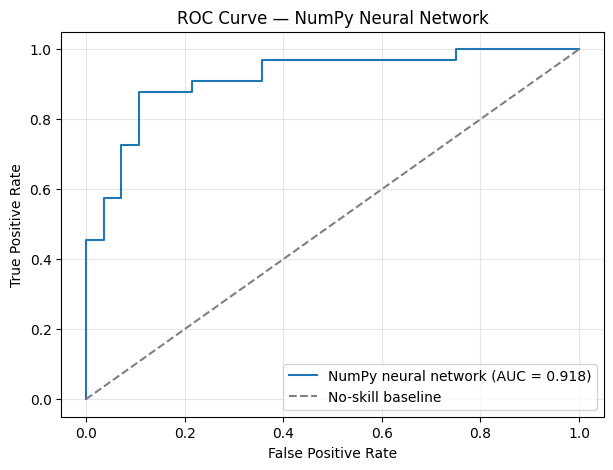

In [37]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probabilities,
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"NumPy neural network (AUC = {test_auc:.3f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="No-skill baseline",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — NumPy Neural Network")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 3: TensorFlow/Keras Implementation

### This section will:
1. Build a small Sequential/Functional model as in the previous section.  
2. Show Loss/metrics for binary classification.   
3. Try a second configuration (activation/optimizer) and compare.  
4. Compare Keras vs. NumPy results.


In [38]:
np.random.seed(15)
import random
random.seed(15)
tf.random.set_seed(15)

In [39]:
# ---- Keras model scaffold ----
def build_keras_baseline(input_dim):
    model1 = keras.Sequential(
        [
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(16, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(1, activation = 'sigmoid')
         ])

    model1.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.01, clipnorm=1.0),
      loss='binary_crossentropy',
      metrics=['accuracy']
    )
    return model1

In [40]:
keras_model1 = build_keras_baseline(input_dim)
print("Model Architecture:")
keras_model1.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = keras_model1.fit(X_train_np, y_train, validation_data=(X_val_np, y_val), epochs=20, batch_size=32, verbose=1)


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.5469 - loss: 0.7320 - val_accuracy: 0.6327 - val_loss: 0.6078
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8854 - loss: 0.4178 - val_accuracy: 0.6939 - val_loss: 0.5308
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8906 - loss: 0.2970 - val_accuracy: 0.7347 - val_loss: 0.5738
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8958 - loss: 0.2511 - val_accuracy: 0.7143 - val_loss: 0.6197
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9219 - loss: 0.2174 - val_accuracy: 0.7347 - val_loss: 0.6312
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9427 - loss: 0.1905 - val_accuracy: 0.7347 - val_loss: 0.6463
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9583 - loss: 0.1654 - val_accuracy: 0.7347 - val_loss: 0.6752
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9688 - loss: 0.1398 - val_accuracy: 0.7347 - val_loss: 0.7236

In [42]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score)
from sklearn.metrics import classification_report

In [43]:
y_predict_1=keras_model1.predict(X_val_np)
y_predict_1 = (y_predict_1 > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


In [44]:
report= classification_report (y_val_np, y_predict_1)
print(report)

              precision    recall  f1-score   support

         0.0       0.65      0.59      0.62        22
         1.0       0.69      0.74      0.71        27

    accuracy                           0.67        49
   macro avg       0.67      0.67      0.67        49
weighted avg       0.67      0.67      0.67        49



In [45]:
y_hat =keras_model1.predict(X_test_np)
y_hat = (y_hat > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


In [46]:
report_t= classification_report (y_test_np, y_hat)
print(report_t)

              precision    recall  f1-score   support

         0.0       0.80      0.86      0.83        28
         1.0       0.87      0.82      0.84        33

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [47]:
score = keras_model1.evaluate(X_test_np, y_test_np, verbose=0)
print('Test Accuracy:', score[1])

Test Accuracy: 0.8360655903816223


In [48]:
# Keras sigmoid probabilities
val_probabilities1 = keras_model1.predict(
    X_val_np,
    verbose=0,
).ravel()

test_probabilities1 = keras_model1.predict(
    X_test_np,
    verbose=0,
).ravel()

print(val_probabilities[:5])
print(test_probabilities[:5])

[0.62141916 0.58994395 0.63915568 0.58286328 0.69690139]
[0.42987513 0.52002594 0.33951311 0.52256515 0.6320814 ]


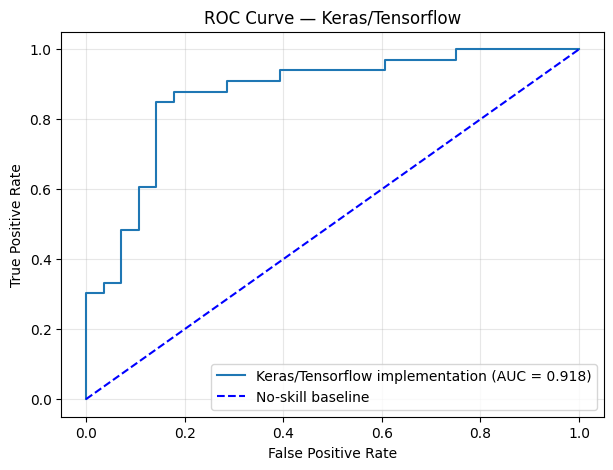

In [49]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probabilities1,
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Keras/Tensorflow implementation (AUC = {test_auc:.3f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="blue",
    label="No-skill baseline",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Keras/Tensorflow")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [50]:
validation_auc1 = roc_auc_score(
    y_val,
    val_probabilities1,
)

test_auc1 = roc_auc_score(
    y_test,
    test_probabilities1,
)

print(f"Validation ROC-AUC: {validation_auc1:.3f}")
print(f"Test ROC-AUC: {test_auc1:.3f}")

Validation ROC-AUC: 0.739
Test ROC-AUC: 0.873


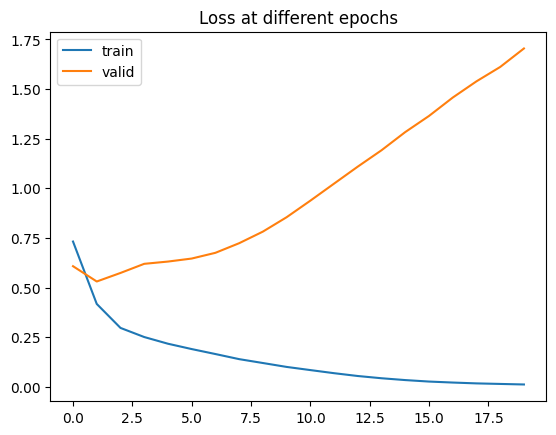

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6735 - loss: 1.7043


In [51]:
hist  = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)
plt.title("Loss at different epochs")
plt.show()

#Printing results
results = keras_model1.evaluate(X_val_np, y_val)

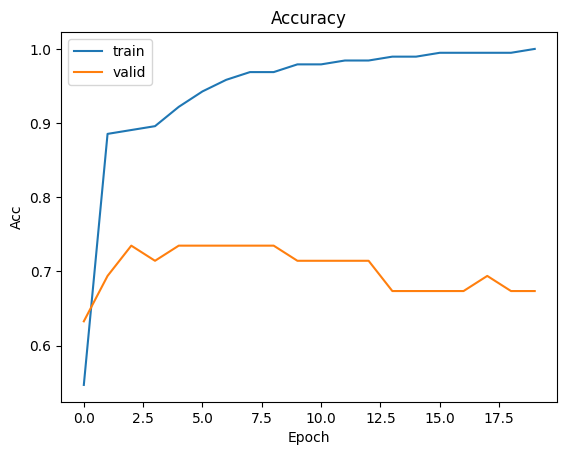

In [52]:
h = next((v.history for v in globals().values() if getattr(v,'history',None) and
isinstance(v.history,dict)), None) or {'accuracy':[],'val_accuracy':[]};
plt.plot(h.get('accuracy', []));
plt.plot(h.get('val_accuracy', []));
plt.xlabel('Epoch');
plt.ylabel('Acc');
plt.legend(("train" , "valid") , loc =0);
plt.title('Accuracy');
plt.show()

##Second configuration with different optimizer (SGD) and activation function Leaky Relu

In [53]:
# ---- Keras model scaffold ----
def build_keras_baseline(input_dim):
    model = keras.Sequential(
        [
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='leaky_relu', kernel_initializer='he_uniform'),
        layers.Dense(16, activation='leaky_relu', kernel_initializer='he_uniform'),
        layers.Dense(1, activation = 'sigmoid')
         ])

    model.compile(
      optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, clipnorm=1.0),
      loss='binary_crossentropy',
      metrics=['accuracy']
    )
    return model

In [54]:
keras_model_2 = build_keras_baseline(input_dim)
print("Model Architecture:")
keras_model_2.summary()

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history2 = keras_model_2.fit(X_train_np, y_train, validation_data=(X_val_np, y_val), epochs=20, batch_size=32, verbose=1)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2344 - loss: 0.8543 - val_accuracy: 0.2857 - val_loss: 0.8044
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2656 - loss: 0.8283 - val_accuracy: 0.3061 - val_loss: 0.7876
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2812 - loss: 0.8051 - val_accuracy: 0.3265 - val_loss: 0.7729
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2865 - loss: 0.7840 - val_accuracy: 0.3469 - val_loss: 0.7596
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3125 - loss: 0.7647 - val_accuracy: 0.3469 - val_loss: 0.7474
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3438 - loss: 0.7470 - val_accuracy: 0.3469 - val_loss: 0.7362
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4167 - loss: 0.7306 - val_accuracy: 0.3878 - val_loss: 0.7257
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4583 - loss: 0.7153 - val_accuracy: 0.4286 - val_loss: 0.7158


In [56]:
y_predict_2=keras_model_2.predict(X_val_np)
y_predict_2 = (y_predict_2 > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [57]:
report2= classification_report (y_val_np, y_predict_2)
print(report2)

              precision    recall  f1-score   support

         0.0       0.69      0.50      0.58        22
         1.0       0.67      0.81      0.73        27

    accuracy                           0.67        49
   macro avg       0.68      0.66      0.66        49
weighted avg       0.68      0.67      0.66        49



In [58]:
y_predict_3=keras_model_2.predict(X_test_np)
y_predict_3 = (y_predict_3 > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [59]:
report3= classification_report (y_test_np, y_predict_3)
print(report3)

              precision    recall  f1-score   support

         0.0       0.73      0.68      0.70        28
         1.0       0.74      0.79      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.73      0.73        61
weighted avg       0.74      0.74      0.74        61



In [60]:
score1 = keras_model_2.evaluate(X_test_np, y_test_np, verbose=0)
print('Test Accuracy:', score1[1])

Test Accuracy: 0.7377049326896667


In [61]:
val_probabilities2 = keras_model_2.predict(
    X_val_np,
    verbose=0,
).ravel()

test_probabilities2 = keras_model_2.predict(
    X_test_np,
    verbose=0,
).ravel()

print(val_probabilities[:5])
print(test_probabilities[:5])

[0.62141916 0.58994395 0.63915568 0.58286328 0.69690139]
[0.42987513 0.52002594 0.33951311 0.52256515 0.6320814 ]


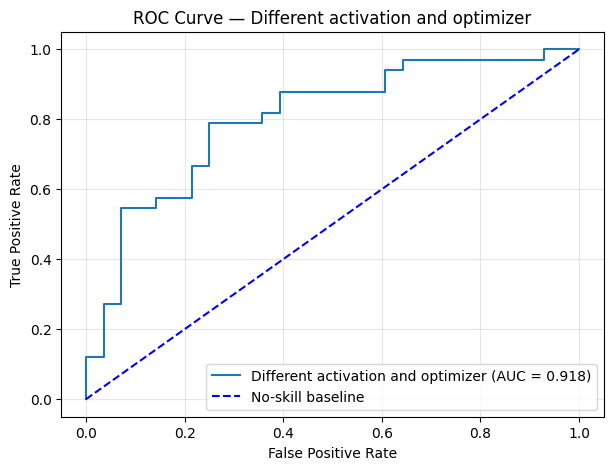

In [62]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probabilities2,
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Different activation and optimizer (AUC = {test_auc:.3f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="blue",
    label="No-skill baseline",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Different activation and optimizer")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [63]:
validation_auc2 = roc_auc_score(
    y_val,
    val_probabilities2,
)

test_auc2 = roc_auc_score(
    y_test,
    test_probabilities2,
)

print(f"Validation ROC-AUC: {validation_auc2:.3f}")
print(f"Test ROC-AUC: {test_auc2:.3f}")

Validation ROC-AUC: 0.712
Test ROC-AUC: 0.802


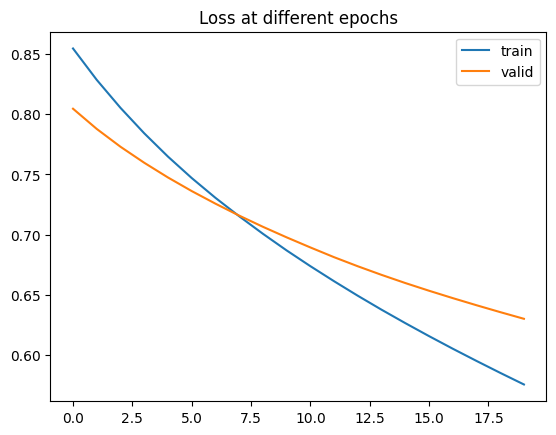

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6735 - loss: 0.6303


In [64]:
hist  = pd.DataFrame(history2.history)
hist['epoch'] = history2.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)
plt.title("Loss at different epochs")
plt.show()

#Printing results
results = keras_model_2.evaluate(X_val_np, y_val)

# Part 4: Analysis of hyperparameters

### In this section:
1. We try different learning rates and hidden sizes.  
2. We train briefly for each configuration.  
3. A simple comparison of evaluation metrics.  
4. Wrap up.


In [65]:
np.random.seed(15)
random.seed(15)
tf.random.set_seed(15)

In [66]:
# ---- Hyperparameter scaffold ----
results = []

for learning_rate in [0.01, 0.001]:
    for hidden_units in [16, 8]:
        tf.keras.utils.set_random_seed(SEED)

        model4 = keras.Sequential([
            layers.Input(
                shape=(X_train_np.shape[1],)
            ),
            layers.Dense(
                hidden_units,
                activation="relu",
                kernel_initializer="he_uniform",
            ),
            layers.Dense(1, activation="sigmoid"),
        ])

        model4.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=learning_rate
            ),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )

        history4 = model4.fit(
            X_train_np,
            y_train,
            validation_data=(X_val_np, y_val),
            epochs=20,
            batch_size=32,
            verbose=0,
        )

        validation_probability = model4.predict(
            X_val_np,
            verbose=0,
        ).ravel()

        results.append({
            "learning_rate": learning_rate,
            "hidden_units": hidden_units,
            "best_validation_accuracy": max(
                history4.history["val_accuracy"]
            ),
            "validation_auc": roc_auc_score(
                y_val,
                validation_probability,
            ),
        })

df_results = pd.DataFrame(results)
display(df_results)

,learning_rate,hidden_units,best_validation_accuracy,validation_auc
0,0.010,16,0.775510,0.804714
1,0.010,8,0.734694,0.804714
2,0.001,16,0.755102,0.808081
3,0.001,8,0.755102,0.784512


In [67]:
y_pred_4=model4.predict(X_val_np)
y_pred_4= (y_pred_4 > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [68]:
y_hat4=model4.predict(X_test_np)
y_hat4= (y_hat4 > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [69]:
report4=classification_report(y_test_np, y_hat4)
print(report4)

              precision    recall  f1-score   support

         0.0       0.69      0.71      0.70        28
         1.0       0.75      0.73      0.74        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



In [70]:
score4 = model4.evaluate(X_test_np, y_test_np, verbose=0)
print('Test Accuracy:', score4[1])

Test Accuracy: 0.7213114500045776


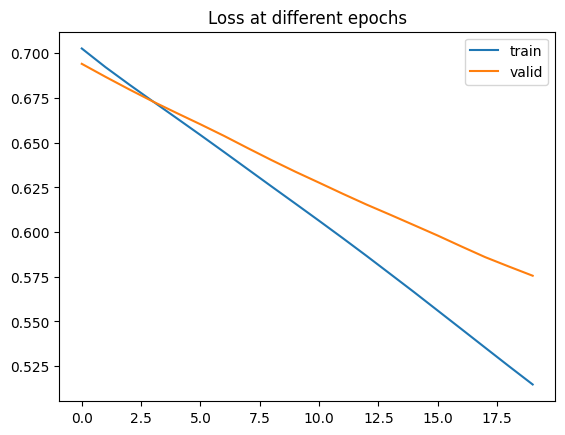

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7551 - loss: 0.5756


In [71]:
hist  = pd.DataFrame(history4.history)
hist['epoch'] = history4.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)
plt.title("Loss at different epochs")
plt.show()

#Printing results
results = model4.evaluate(X_val_np, y_val)

In [72]:
val_probabilities4 = model4.predict(
    X_val_np,
    verbose=0,
).ravel()

test_probabilities4 = model4.predict(
    X_test_np,
    verbose=0,
).ravel()

print(val_probabilities[:5])
print(test_probabilities[:5])

[0.62141916 0.58994395 0.63915568 0.58286328 0.69690139]
[0.42987513 0.52002594 0.33951311 0.52256515 0.6320814 ]


Best Threshold=0.509788, G-Mean=0.739


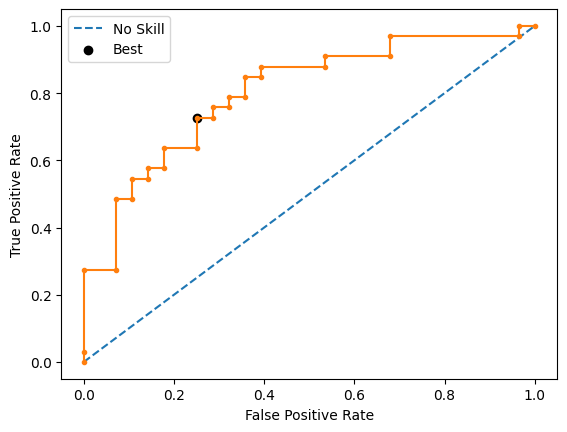

In [81]:
from matplotlib import pyplot
# predict probabilities
fpr2, tpr2, thresholds2 = roc_curve(y_test, test_probabilities4)

gmeans2 = np.sqrt(tpr2 * (1 - fpr2))
ix = np.argmax(gmeans2)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds2[ix], gmeans2[ix]))

pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr2, tpr2, marker='.')
pyplot.scatter(fpr2[ix], tpr2[ix], marker='o', color='black', label='Best')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
# show the plot
pyplot.show()

In [74]:
validation_auc4 = roc_auc_score(
    y_val,
    val_probabilities4,
)

test_auc4 = roc_auc_score(
    y_test,
    test_probabilities4,
)

print(f"Validation ROC-AUC: {validation_auc4:.3f}")
print(f"Test ROC-AUC: {test_auc4:.3f}")

Validation ROC-AUC: 0.785
Test ROC-AUC: 0.802


# Part 5: Summary


In [75]:
# Classification reports
print("\nClassification Report on test data:")
print("\n1. Numpy:")
print(classification_report(y_test, test_predictions, target_names=['Class 0', 'Class 1']))

print("\n2. Keras with ADAM and RELU:")
print(classification_report(y_test, y_hat, target_names=['Class 0', 'Class 1']))

print("\n3. Keras with SGD and LEAKY RELU:")
print(classification_report(y_test, y_predict_3, target_names=['Class 0', 'Class 1']))

print("\n3. Hyperparameter analysis:")
print(classification_report(y_test, y_hat4, target_names=['Class0', 'Class 1']))



Classification Report on test data:

1. Numpy:
              precision    recall  f1-score   support

     Class 0       0.88      0.75      0.81        28
     Class 1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61


2. Keras with ADAM and RELU:
              precision    recall  f1-score   support

     Class 0       0.80      0.86      0.83        28
     Class 1       0.87      0.82      0.84        33

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


3. Keras with SGD and LEAKY RELU:
              precision    recall  f1-score   support

     Class 0       0.73      0.68      0.70        28
     Class 1       0.74      0.79      0.76        33

    accuracy                           0.74        61
   macro avg   

In [76]:
# Compile results for comparison
results_df = pd.DataFrame({
    'Framework': ['Neural Network Numpy', 'Keras model', 'Keras model 2', 'Hyperparameter analysis'],
    'AUC_ROC_score': [test_auc, test_auc1, test_auc2, test_auc4],
})

print("\nFramework Comparison Summary:")
print(results_df.round(4))



Framework Comparison Summary:
                 Framework  AUC_ROC_score
0     Neural Network Numpy         0.9177
1              Keras model         0.8734
2            Keras model 2         0.8019
3  Hyperparameter analysis         0.8019


In [77]:
model_comparison =pd.DataFrame ({'Model':['TinyNumpy', 'Keras','Keras w/SGD ','Keras w/lr'],
                               'Test Accuracy':[0.84, score[1], score1[1], score4[1]], 'AUC_ROC score':[ test_auc, test_auc1, test_auc2, test_auc4]})
model_comparison

,Model,Test Accuracy,AUC_ROC score
0,TinyNumpy,0.840000,0.917749
1,Keras,0.836066,0.873377
2,Keras w/SGD,0.737705,0.801948
3,Keras w/lr,0.721311,0.801948


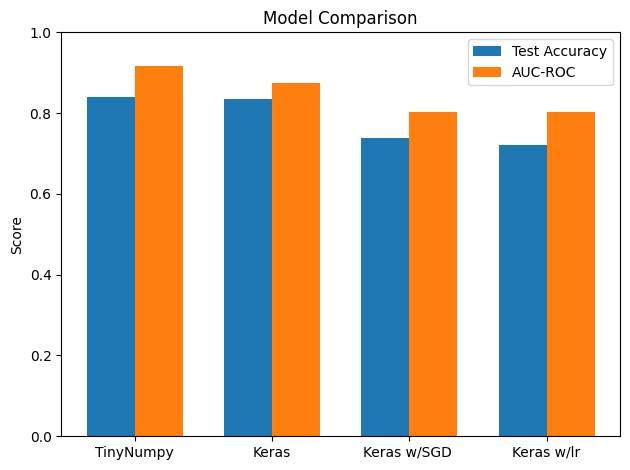

In [78]:
models = model_comparison['Model']
accuracy = model_comparison['Test Accuracy']
auc = model_comparison['AUC_ROC score']

x = np.arange(len(models))  # label locations
width = 0.35                # width of the bars

plt.figure()
plt.bar(x - width/2, accuracy, width, label='Test Accuracy')
plt.bar(x + width/2, auc, width, label='AUC-ROC')

# Labels & formatting
plt.xticks(x, models, rotation=0)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Wrap up


This case study uses one of the various versions of the heart disease database from 1988, compiled from four sources: Cleveland, Hungary, Switzerland, and Long Beach V. The target variable refers to the presence of heart disease in the patient and is integer-valued, where 0 indicates no disease and 1 indicates disease.

The data catalogue includes variables that may be indicators of ischaemic heart disease, such as cholesterol levels, blood pressure, and electrocardiographic results, among others. A neural network can therefore predict this condition with a good degree of accuracy.

This is my first neural network built from scratch. The first model implements a neural network in NumPy, with the forward and backward propagation coded manually. The subsequent models are built with Keras and TensorFlow, after which I experimented with different optimisers and activation functions. In the final model, I explored different learning rates and hidden layer sizes. This could certainly be done using Grid Search or other more streamlined techniques; however, my aim here was first to understand how the process works manually.

Writing and implementing neural networks with the TensorFlow and Keras libraries is much faster, as they simplify the mathematical operations involved in training and make it easier to build several models. This approach also allows greater focus on tuning the models for generalisation. A NumPy neural network requires more epochs to perform well, whereas the Keras models can be trained in fewer.

At the end of the notebook there are a few tables where you can compare the evaluation metrics and the ROC-AUC scores.

If you are studying deep learning, you are welcome to use this notebook and to leave comments.  

